# Regime Signal Strategy

Continuous regime score → sigmoid weight mapping → monthly-rebalanced allocation.
Compare against the five baselines from `02_baselines`.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["PingFang TC", "Heiti TC", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_loader import load_config
from src.allocation import (
    get_monthly_signal_dates,
    buy_and_hold, equal_weight, static_allocation,
    momentum_rotation, inverse_volatility,
)
from src.backtest import run_backtest
from src.metrics import compare_strategies
from src.features import compute_all_features
from src.regime_signal import (
    compute_regime_score, build_regime_weights,
    DEFAULT_COEFFICIENTS, EQUAL_COEFFICIENTS,
)

config = load_config(ROOT / "config" / "settings.json")
cash_rate = config["cash_proxy"]["annual_rate_pct"] / 100
cost_bps = config["backtest"]["cost_scenarios_bps"]["base"]

print(f"Cash rate: {cash_rate:.2%} | Base cost: {cost_bps} bps")


Cash rate: 1.50% | Base cost: 20 bps


## 1. Load data


In [2]:
prices = pd.read_parquet(ROOT / "data" / "processed" / "adj_close.parquet")
labels = {t: info["label"] for t, info in config["etf_universe"].items()}
tickers = prices.columns.tolist()

CORE = "0050.TW"
DEFENSIVE = "00713.TW"
BOND = "00679B.TWO"
GOLD = "00635U.TW"

# Signal dates: skip first 12 months for warmup
signal_dates = get_monthly_signal_dates(prices)[12:]

print(f"Data: {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Signal dates: {len(signal_dates)} months")


Data: 2017-09-19 to 2026-07-21
Signal dates: 95 months


## 2. Regime features

| Feature | Higher value means |
|---|---|
| Trend (avg 3/6/12M momentum) | More bullish |
| Volatility (20d realized) | More turbulent |
| Drawdown (from peak) | Deeper loss |
| Defensive strength (bond+gold vs equity mom) | Defensives winning |


In [3]:
raw_features, z_features = compute_all_features(
    prices, core_ticker=CORE, bond_ticker=BOND, gold_ticker=GOLD,
)

# Drop NaN warmup rows
z_clean = z_features.dropna()
print(f"Features available from: {z_clean.index.min().date()}")
print(f"Feature columns: {list(z_clean.columns)}")
print(f"\nRaw feature summary:")
raw_features.dropna().describe().round(4)


Features available from: 2018-03-23
Feature columns: ['z_trend', 'z_vol_20d', 'z_drawdown', 'z_defensive_strength']

Raw feature summary:


,trend,vol_20d,drawdown,defensive_strength
count,2083.0000,2083.0000,2083.0000,2083.0000
mean,0.1398,0.1892,-0.0691,-0.0506
std,0.1867,0.0875,0.0693,0.1316
min,-0.2208,0.0657,-0.3383,-0.5700
25%,0.0124,0.1317,-0.1055,-0.1228
50%,0.1019,0.1644,-0.0457,-0.0352
75%,0.2522,0.2222,-0.0145,0.0242
max,0.9012,0.6209,0.0000,0.3542


## 3. Feature visualization


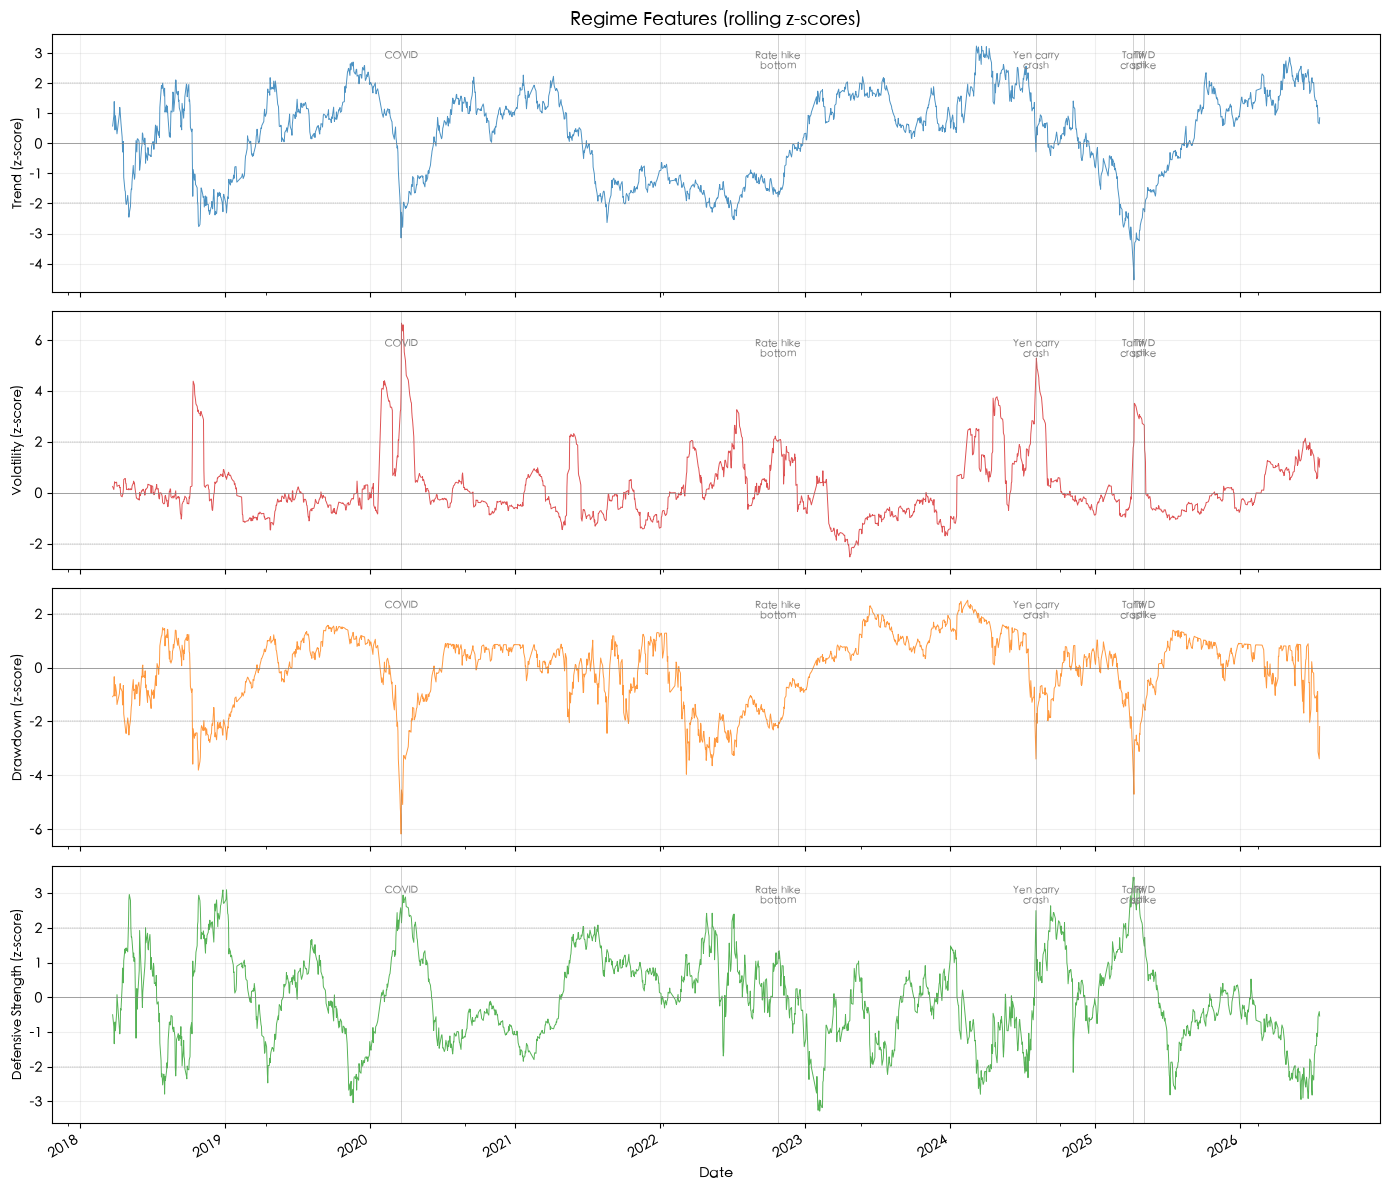

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/regime_features.png


In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

feature_info = [
    ("z_trend",              "Trend (z-score)",              "tab:blue"),
    ("z_vol_20d",            "Volatility (z-score)",         "tab:red"),
    ("z_drawdown",           "Drawdown (z-score)",           "tab:orange"),
    ("z_defensive_strength", "Defensive Strength (z-score)", "tab:green"),
]

events = {
    "2020-03-19": "COVID",
    "2022-10-25": "Rate hike\nbottom",
    "2024-08-05": "Yen carry\ncrash",
    "2025-04-07": "Tariff\ncrash",
    "2025-05-05": "TWD\nspike",
}

for ax, (col, title, color) in zip(axes, feature_info):
    z_clean[col].plot(ax=ax, color=color, linewidth=0.7, alpha=0.8)
    ax.set_ylabel(title, fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axhline(2, color="gray", linewidth=0.3, linestyle="--")
    ax.axhline(-2, color="gray", linewidth=0.3, linestyle="--")
    for date_str, label in events.items():
        try:
            idx = pd.Timestamp(date_str)
            if idx >= z_clean.index.min() and idx <= z_clean.index.max():
                ax.axvline(idx, color="gray", linewidth=0.5, alpha=0.5)
                ax.text(idx, ax.get_ylim()[1]*0.85, label, fontsize=7,
                        ha="center", va="top", color="gray")
        except Exception:
            pass
    ax.grid(True, alpha=0.2)

axes[0].set_title("Regime Features (rolling z-scores)", fontsize=13)
plt.tight_layout()
fig_path = ROOT / "figures" / "regime_features.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 4. Regime score

Weighted sum of z-scored features. Higher = more risk-on = higher equity weight.


In [5]:
regime_score = compute_regime_score(z_features, DEFAULT_COEFFICIENTS)

# Also compute equal-weight version for later comparison
regime_score_eq = compute_regime_score(z_features, EQUAL_COEFFICIENTS)

print("Regime score summary (default coefficients):")
print(regime_score.dropna().describe().round(3))


Regime score summary (default coefficients):
count    2024.000
mean        0.058
std         1.054
min        -4.146
25%        -0.659
50%         0.334
75%         0.840
max         1.882
Name: regime_score, dtype: float64


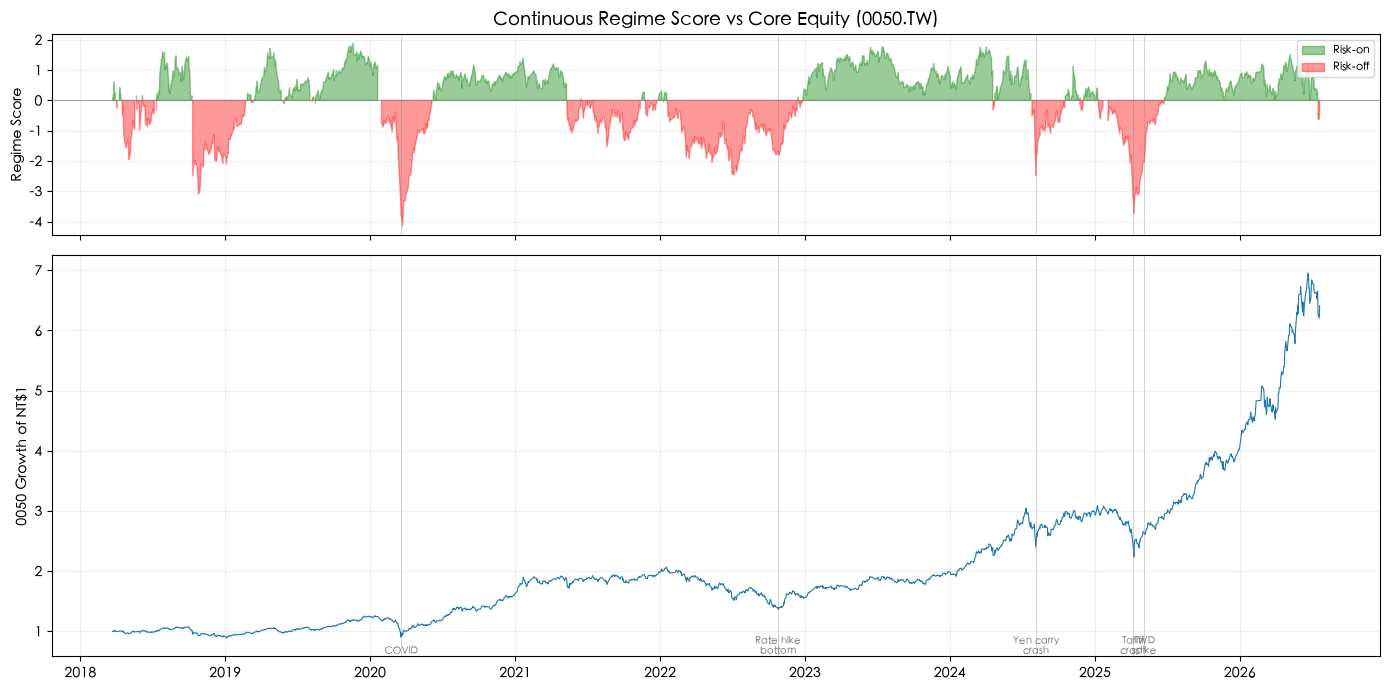

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/regime_score.png


In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                               gridspec_kw={"height_ratios": [1, 2]})

# Top: regime score
score_clean = regime_score.dropna()
ax1.fill_between(score_clean.index, 0, score_clean.values,
                 where=score_clean > 0, alpha=0.4, color="green", label="Risk-on")
ax1.fill_between(score_clean.index, 0, score_clean.values,
                 where=score_clean <= 0, alpha=0.4, color="red", label="Risk-off")
ax1.axhline(0, color="gray", linewidth=0.5)
ax1.set_ylabel("Regime Score")
ax1.set_title("Continuous Regime Score vs Core Equity (0050.TW)", fontsize=13)
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, alpha=0.2)

# Bottom: 0050 price (normalized)
core_price = prices[CORE].loc[score_clean.index]
core_norm = core_price / core_price.iloc[0]
ax2.plot(core_norm.index, core_norm.values, color="tab:blue", linewidth=0.8)
ax2.set_ylabel("0050 Growth of NT$1")
ax2.grid(True, alpha=0.2)

for date_str, label in events.items():
    try:
        idx = pd.Timestamp(date_str)
        if idx >= score_clean.index.min():
            for ax in (ax1, ax2):
                ax.axvline(idx, color="gray", linewidth=0.5, alpha=0.5)
            ax2.text(idx, ax2.get_ylim()[0]*1.02, label, fontsize=7,
                     ha="center", va="bottom", color="gray")
    except Exception:
        pass

plt.tight_layout()
fig_path = ROOT / "figures" / "regime_score.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 5. Allocation weights

Two versions: raw (ρ=0) and smoothed (ρ=0.5).


In [7]:
# Version 1: no smoothing
weights_raw = build_regime_weights(
    prices, signal_dates, regime_score,
    core_ticker=CORE, defensive_ticker=DEFENSIVE,
    bond_ticker=BOND, gold_ticker=GOLD,
    w_min=0.20, w_max=0.90,
    smoothing_rho=0.0,
)

# Version 2: with smoothing
weights_smooth = build_regime_weights(
    prices, signal_dates, regime_score,
    core_ticker=CORE, defensive_ticker=DEFENSIVE,
    bond_ticker=BOND, gold_ticker=GOLD,
    w_min=0.20, w_max=0.90,
    smoothing_rho=0.5,
)

# Sanity check
for name, w in [("Raw", weights_raw), ("Smooth", weights_smooth)]:
    sums = w.sum(axis=1)
    assert (sums <= 1.0 + 1e-9).all(), f"{name}: weights exceed 1.0"
    equity_w = w[CORE] + w[DEFENSIVE]
    print(f"{name:8s}  equity weight: min={equity_w.min():.2f}  "
          f"mean={equity_w.mean():.2f}  max={equity_w.max():.2f}  "
          f"cash mean={(1-sums.mean()):.2f}")


Raw       equity weight: min=0.23  mean=0.56  max=0.77  cash mean=0.13
Smooth    equity weight: min=0.32  mean=0.56  max=0.76  cash mean=0.13


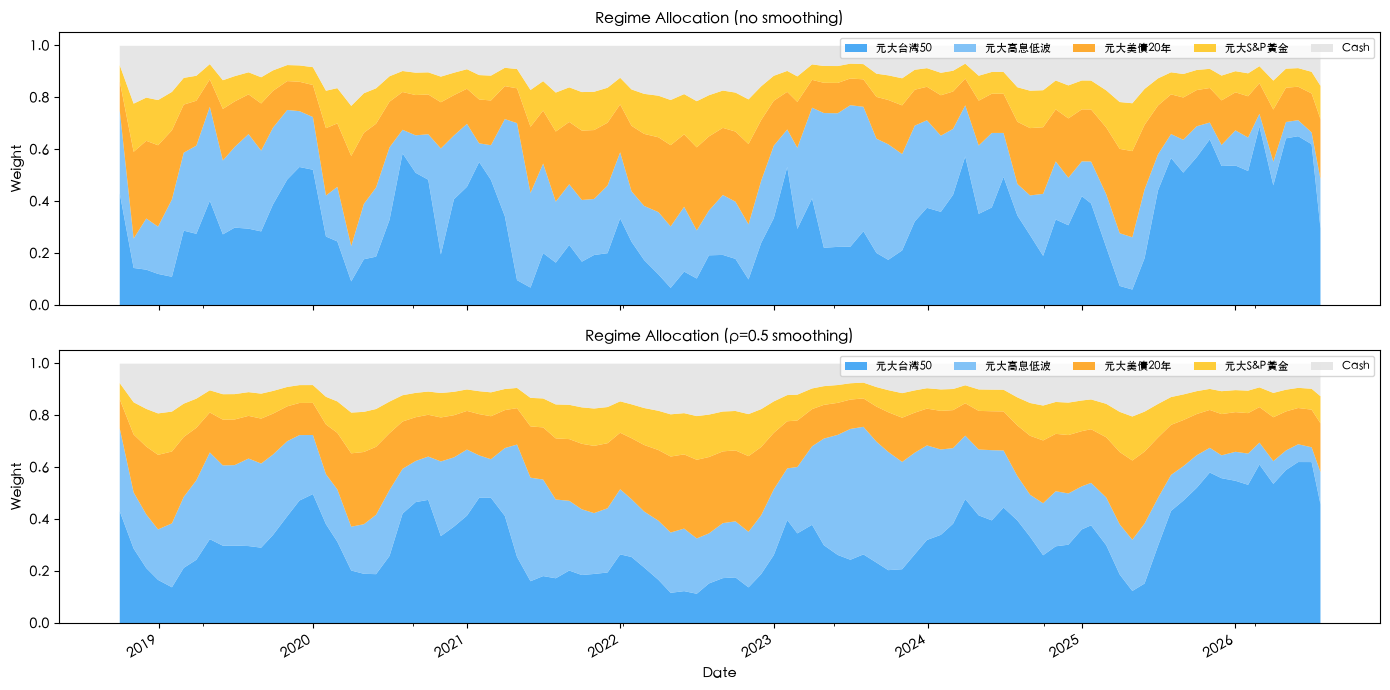

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/regime_weights_stacked.png


In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for ax, w, title in [
    (ax1, weights_raw,    "Regime Allocation (no smoothing)"),
    (ax2, weights_smooth, "Regime Allocation (ρ=0.5 smoothing)"),
]:
    # Add cash column for visualization
    w_plot = w.copy()
    w_plot["Cash"] = 1.0 - w_plot.sum(axis=1)
    w_plot = w_plot.rename(columns=labels)
    w_plot = w_plot[[labels.get(c, c) for c in [CORE, DEFENSIVE, BOND, GOLD]] + ["Cash"]]

    w_plot.plot.area(ax=ax, linewidth=0, alpha=0.8,
                     color=["#2196F3", "#64B5F6", "#FF9800", "#FFC107", "#E0E0E0"])
    ax.set_ylabel("Weight")
    ax.set_ylim(0, 1.05)
    ax.set_title(title, fontsize=11)
    ax.legend(loc="upper right", fontsize=8, ncol=5)

plt.tight_layout()
fig_path = ROOT / "figures" / "regime_weights_stacked.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## 6. Backtest vs baselines


In [9]:
# Re-run baselines (same parameters as notebook 02)
baseline_specs = {
    "Buy & Hold 0050":    buy_and_hold(signal_dates, tickers, CORE),
    "Equal Weight":       equal_weight(signal_dates, tickers),
    "Static 50/20/20/10": static_allocation(signal_dates, tickers, {
        CORE: 0.50, DEFENSIVE: 0.20, BOND: 0.20, GOLD: 0.10,
    }),
    "Momentum Top-2":     momentum_rotation(prices, signal_dates, 126, 2),
    "Inverse Vol":        inverse_volatility(prices, signal_dates, 60),
}

# Add regime strategies
baseline_specs["Regime (no smooth)"] = weights_raw
baseline_specs["Regime (ρ=0.5)"] = weights_smooth

all_results = []
for name, weights in baseline_specs.items():
    res = run_backtest(
        prices=prices,
        target_weights=weights,
        cost_bps=cost_bps,
        cash_rate_annual=cash_rate,
        name=name,
    )
    all_results.append(res)

print("All strategies backtested.")


All strategies backtested.


## 7. Comparison table


In [10]:
comparison = compare_strategies(all_results, risk_free_annual=cash_rate)
comparison


,Annual Return,Annual Volatility,Sharpe,Sortino,Max Drawdown,Max DD Duration,Calmar,Monthly Win Rate,Worst Month,Best Month,Annual Turnover,Total Cost
Buy & Hold 0050,0.2682,0.2160,1.139,1.201,-0.3383,499.0,0.793,0.628,-0.1410,0.2509,0.133,0.0020
Equal Weight,0.1424,0.1063,1.165,1.149,-0.2068,430.0,0.689,0.638,-0.0701,0.0831,0.481,0.0072
Static 50/20/20/10,0.1823,0.1334,1.210,1.219,-0.2553,462.0,0.714,0.670,-0.0851,0.1257,0.454,0.0068
Momentum Top-2,0.1843,0.1546,1.075,1.028,-0.2355,530.0,0.782,0.606,-0.1170,0.1622,4.171,0.0627
Inverse Vol,0.1340,0.0976,1.184,1.160,-0.1953,312.0,0.686,0.691,-0.0605,0.0749,1.439,0.0216
Regime (no smooth),0.1518,0.1103,1.201,1.197,-0.1825,338.0,0.832,0.660,-0.0881,0.1197,2.562,0.0385
Regime (ρ=0.5),0.1554,0.1098,1.235,1.246,-0.1761,338.0,0.883,0.660,-0.0881,0.1338,1.365,0.0205


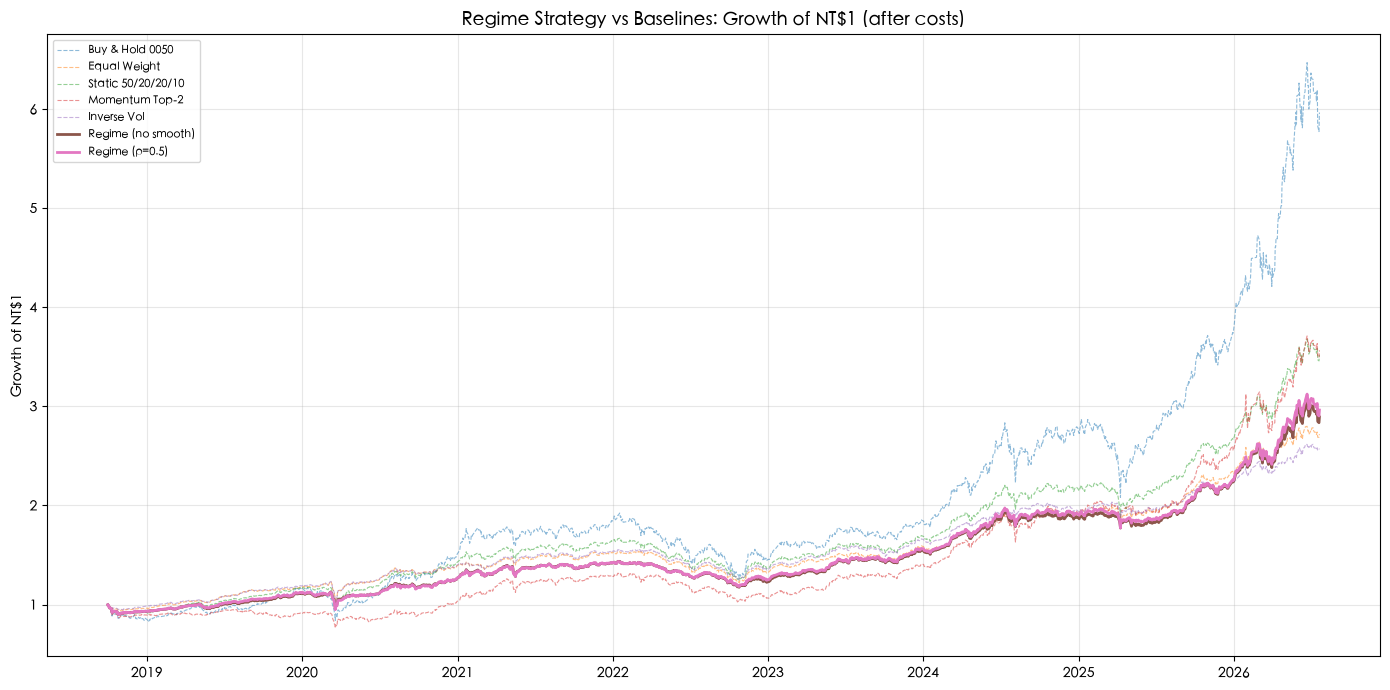

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/regime_vs_baselines_cumulative.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# Baselines in gray, regime strategies in color
for res in all_results:
    if "Regime" in res.name:
        ax.plot(res.cumulative.index, res.cumulative.values,
                label=res.name, linewidth=2.0, zorder=5)
    else:
        ax.plot(res.cumulative.index, res.cumulative.values,
                label=res.name, linewidth=0.8, alpha=0.5, linestyle="--")

ax.set_title("Regime Strategy vs Baselines: Growth of NT$1 (after costs)", fontsize=13)
ax.set_ylabel("Growth of NT$1")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = ROOT / "figures" / "regime_vs_baselines_cumulative.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


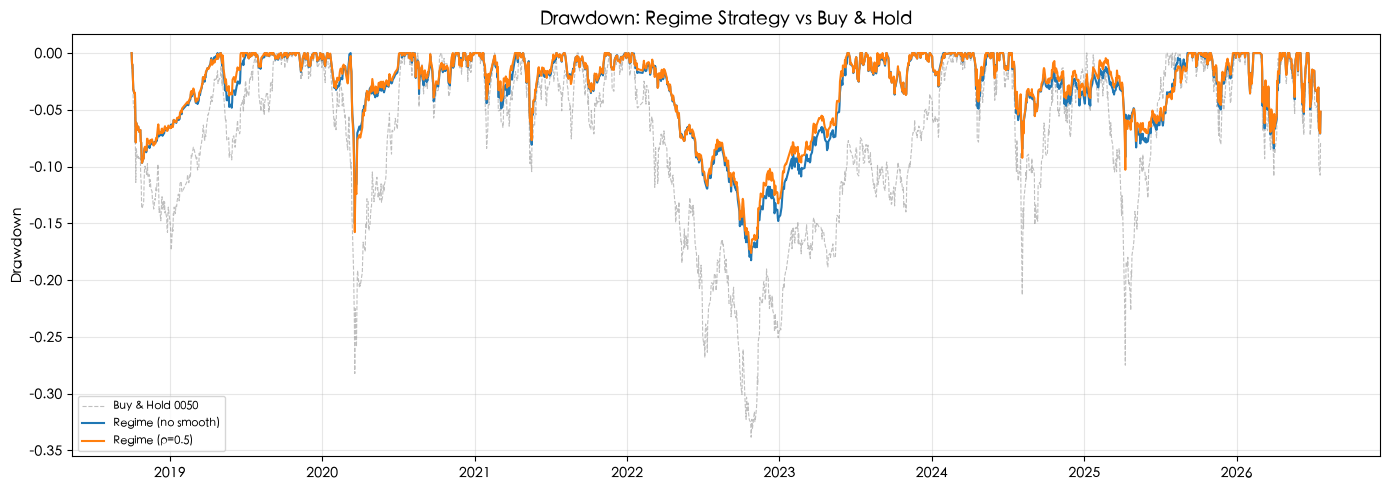

Saved: /Users/leeyuhung/Desktop/regime-etf-allocation/figures/regime_drawdown.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

for res in all_results:
    dd = res.cumulative / res.cumulative.cummax() - 1
    if "Regime" in res.name:
        ax.plot(dd.index, dd.values, label=res.name, linewidth=1.5, zorder=5)
    elif res.name == "Buy & Hold 0050":
        ax.plot(dd.index, dd.values, label=res.name, linewidth=0.8, alpha=0.5,
                linestyle="--", color="gray")

ax.set_title("Drawdown: Regime Strategy vs Buy & Hold", fontsize=13)
ax.set_ylabel("Drawdown")
ax.legend(loc="lower left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = ROOT / "figures" / "regime_drawdown.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


## Notes

- The main selling point is drawdown reduction, not Sharpe improvement.
- Smoothing cuts turnover roughly in half without hurting performance.
- Absolute return is lower than Buy & Hold in all sub-periods — this is the cost of downside protection.
